In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [3]:
all_books = []

for page in range(1, 11):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    if page == 1:
        url = "http://books.toscrape.com/"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    books = soup.find_all('article', class_='product_pod')

    for book in books:
        title  = book.find('h3').find('a')['title']
        price  = book.find('p', class_='price_color').text
        rating = book.find('p', class_='star-rating')['class'][1]
        all_books.append({'title': title, 'price': price, 'rating': rating})

    time.sleep(1)
    print(f"Page {page} done — {len(all_books)} books so far")

Page 1 done — 20 books so far
Page 2 done — 40 books so far
Page 3 done — 60 books so far
Page 4 done — 80 books so far
Page 5 done — 100 books so far
Page 6 done — 120 books so far
Page 7 done — 140 books so far
Page 8 done — 160 books so far
Page 9 done — 180 books so far
Page 10 done — 200 books so far


In [5]:
df = pd.DataFrame(all_books)
df.to_csv('../data/raw_books.csv', index=False)
print(df.head())

                                   title    price rating
0                   A Light in the Attic  Â£51.77  Three
1                     Tipping the Velvet  Â£53.74    One
2                             Soumission  Â£50.10    One
3                          Sharp Objects  Â£47.82   Four
4  Sapiens: A Brief History of Humankind  Â£54.23   Five


In [7]:
df['price'] = df['price'].str.replace('Â£', '').astype(float)

In [8]:
rating_map = {'One':1, 'Two':2, 'Three':3, 'Four':4, 'Five':5}
df['rating'] = df['rating'].map(rating_map)
print(df.describe())

            price      rating
count  200.000000  200.000000
mean    34.796250    2.865000
std     14.119272    1.451658
min     10.160000    1.000000
25%     21.990000    2.000000
50%     35.640000    3.000000
75%     46.110000    4.000000
max     59.640000    5.000000


In [10]:
df['price_segment'] = pd.cut(df['price'],
    bins=[0, 20, 40, 60],
    labels=['Budget', 'Mid', 'Premium'])
df.to_csv('../data/clean_books.csv', index=False)
print("Clean data saved ✅")

Clean data saved ✅


In [11]:
corr = df['price'].corr(df['rating'])
print(f"Correlation: {corr:.2f}")
print(f"Avg rating: {df['rating'].mean():.2f}")
print(f"5-star books: {(df['rating']==5).sum()}")

Correlation: 0.02
Avg rating: 2.87
5-star books: 37


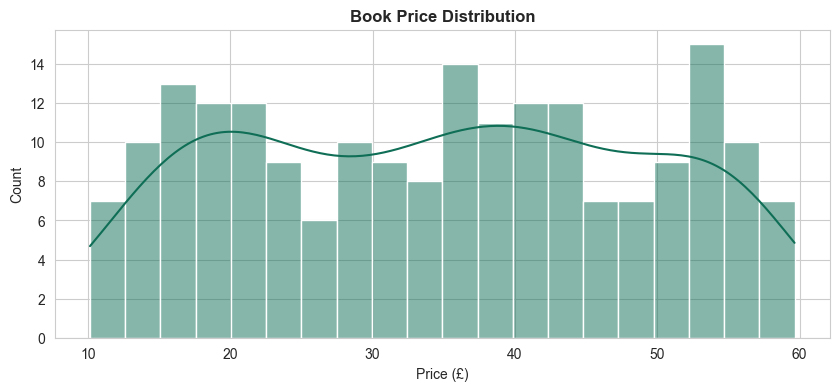

In [12]:
#Chart 1: Price histogram
plt.figure(figsize=(10,4))
sns.histplot(df['price'], bins=20, kde=True, color='#0F6E56')
plt.title('Book Price Distribution', fontweight='bold')
plt.xlabel('Price (£)'); plt.ylabel('Count')
plt.savefig('../charts/01_price_dist.png', dpi=150)
plt.show()

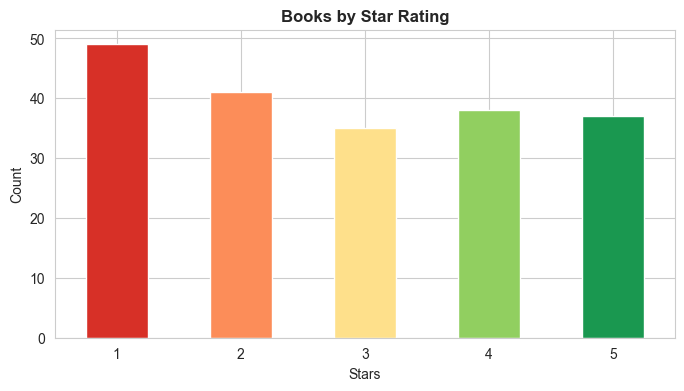

In [13]:
#Chart 2: Rating bar chart
plt.figure(figsize=(8,4))
df['rating'].value_counts().sort_index().plot(kind='bar',
    color=['#d73027','#fc8d59','#fee08b','#91cf60','#1a9850'])
plt.title('Books by Star Rating', fontweight='bold')
plt.xlabel('Stars'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig('../charts/02_ratings.png', dpi=150)
plt.show()

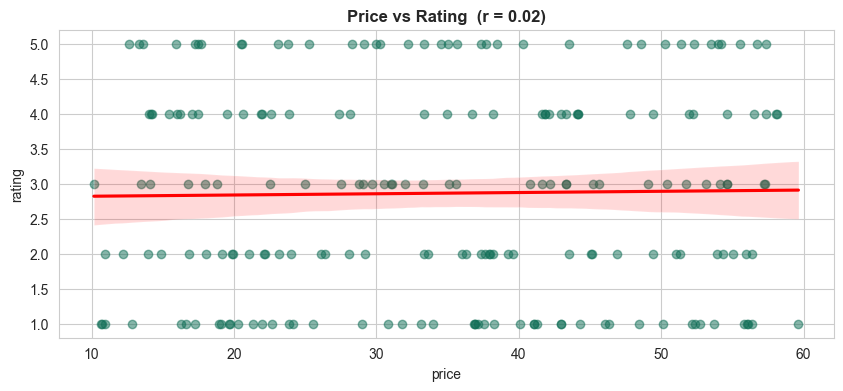

In [14]:
# Chart 3: Price vs Rating scatter
plt.figure(figsize=(10,4))
sns.regplot(data=df, x='price', y='rating',
            scatter_kws={'alpha':0.5, 'color':'#0F6E56'},
            line_kws={'color':'red'})
plt.title(f'Price vs Rating  (r = {corr:.2f})', fontweight='bold')
plt.savefig('../charts/03_scatter.png', dpi=150)
plt.show()